In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as const
import astropy.constants as aconst
from simple_pe.waveforms import make_waveform

/home/ben.patterson/.conda/envs/igwn_eccentric_new/lib/python3.10/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
/home/ben.patterson/.conda/envs/igwn_eccentric_new/lib/python3.10/site-packages/pykerr/qnm.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this p

lal.MSUN_SI != Msun


In [221]:
f_low = 5.63
e = 0.8
m1 = 40*aconst.M_sun.value
m2 = 80*aconst.M_sun.value

In [213]:
time

3.557202811340648

In [212]:
t_orb = 2/(f_low)
a = (const.G*(m1+m2)*t_orb**2/(4*np.pi**2))**(1/3)
f_e = (1-e**2)/e**(12/19)*(1 + 121/304*e**2)**(-870/2299)
c0 = a*f_e
beta = 64/5*const.G**3*m1*m2*(m1+m2)/const.c**5
es = np.linspace(0, e, 500)
integrand = es**(29/19)*(1 + 121/304*es**2)**(1181/2299)/(1-es**2)**(3/2)
time = 12/19*c0**4/beta*np.trapz(integrand, es)
print(time/t_orb)

10.013525913923925


In [ ]:
def calc_f_orbits(f_ref, e, m1, m2, x):

    # Calculate constants
    m1 *= aconst.M_sun.value
    m2 *= aconst.M_sun.value
    t_orb = 2/f_ref
    a = (const.G*(m1+m2)*t_orb**2/(4*np.pi**2))**(1/3)
    f_e = (1-e**2)/e**(12/19)*(1 + 121/304*e**2)**(-870/2299)
    c_0 = a*f_e
    beta = 64/5*const.G**3*m1*m2*(m1+m2)/const.c**5

    # Create interpolation function and interpolate
    f_interps = np.linspace(0, 100, 10**6)[1:]
    e_interps = shifted_e(f_interps, f_ref, e)
    es = np.linspace(0, e, 500)
    integrand = es**(29/19)*(1 + 121/304*es**2)**(1181/2299)/(1-es**2)**(3/2)
    integral = np.trapz(integrand, es)
    x_interps = (6/19)*f_interps
    f_interps = constant*e_term_1*e_term_2*e_term_3
    f_interps = np.insert(f_interps, 0, np.inf)
    e_interps = np.insert(e_interps, 0, 0)
    ef_interp_fn = interp1d(f_interps, e_interps)

    try:
        s_e = ef_interp_fn(s_f)
    except ValueError:
        raise ValueError(f'shifted_e interp failed with s_f={s_f}, '
                         + f'f={f}, e={e}')

    return s_e


In [232]:
x = 100
f_e = (1-e**2)/e**(12/19)*(1 + 121/304*e**2)**(-870/2299)
beta = 64/5*const.G**3*m1*m2*(m1+m2)/const.c**5
prefactor = (12/19)*(const.G*(m1+m2)/(4*np.pi**2))**(4/3)
es = np.linspace(0, e, 500)
integrand = es**(29/19)*(1 + 121/304*es**2)**(1181/2299)/(1-es**2)**(3/2)
integral = np.trapz(integrand, es)
f_low = 2*(prefactor*(1/x)*f_e**4/beta*integral)**(3/5)
print(f_low)

0.3137723052729844


2026-05-11  16:10:32 PESummary WARNING : Could not find f_final in input file and one was not passed from the command line. Using 1024.0Hz as default
2026-05-11  16:10:32 PESummary WARNING : Could not find f_start in input file and one was not passed from the command line. Using 20.0Hz as default


(-1.0, 0.1)

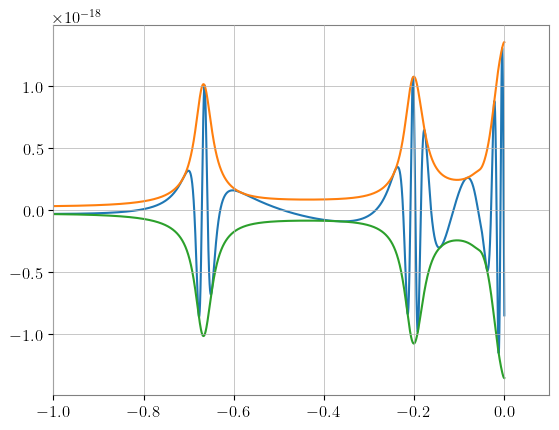

In [240]:
params = {'total_mass': 120, 'mass_ratio': 0.5, 'chi_align': 0, 'ecc10sqrd': 0.6**2}
hp, hc = make_waveform(params, 1/32, 0.0001, int(32*4096)//2+1, 'TEOBResumS-Dali', return_hc=True)
hp_ts = hp.to_timeseries()
hc_ts = hc.to_timeseries()
plt.plot(hp_ts.sample_times, hp_ts)
plt.plot(hp_ts.sample_times, np.sqrt(hp_ts**2+hc_ts**2))
plt.plot(hp_ts.sample_times, -np.sqrt(hp_ts**2+hc_ts**2))
plt.xlim(-1,0.1)